# Special relativity with xarrayrf

xarrayrf attaches reference frames to arrays and moves data between frames with explicit
transforms. Nothing in it is specific to images: an inertial frame is a reference frame, a
Lorentz boost is an affine transform, and a field sampled over spacetime is a `DataArray`.
This notebook uses that to *measure* relativistic effects on sampled objects: relativity of
simultaneity, length contraction, desynchronized clocks and time dilation.

Units are natural: `ct` and positions in metres, velocities as fractions of c. No physics code
lives in xarrayrf; the few lines of physics (a boost matrix, what "length" means) are here.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from matplotlib.colors import LinearSegmentedColormap

import xarrayrf as xrf
import xarrayrf.native  # registers the .rf accessor

BLUE, ORANGE, INK = "#2a78d6", "#eb6834", "#52514e"
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})


def spacetime(spatial_dims):
    """Coordinates (ct, x, ...) in metres."""
    axes = ("ct", "x", "y", "z")[: spatial_dims + 1]
    return xrf.CoordinateSystem(axes, ("m",) * len(axes))


def boost(beta):
    """Lorentz boost into the frame moving with velocity beta (in units of c)."""
    beta = np.atleast_1d(np.asarray(beta, float))
    gamma = 1 / np.sqrt(1 - beta @ beta)
    matrix = np.eye(beta.size + 1)
    matrix[0, 0] = gamma
    matrix[0, 1:] = matrix[1:, 0] = -gamma * beta
    matrix[1:, 1:] += (gamma - 1) * np.outer(beta, beta) / (beta @ beta)
    return matrix, gamma


def grid(frame, **axes):
    """An empty field sampled on the given axes of a spacetime frame."""
    names = frame.coordinate_system.axes
    values = np.zeros([len(axes[name]) for name in names])
    identity = xrf.AffineTransform(
        source=xrf.ArrayCoordinates(names, ("m",) * len(names)),
        target=frame,
        matrix=np.eye(len(names)),
        translation=np.zeros(len(names)),
    )
    array = xr.DataArray(values, dims=names, coords={name: axes[name] for name in names})
    return array.rf.frame(identity, dims=names)

## 1. Simultaneity: whose "now"?

An object at rest in its own frame traces a band (its *worldtube*) through spacetime. Sampled in
its rest frame, the band is vertical. Resample the whole spacetime field into a laboratory
frame in which the object moves at 0.6 c, and the band tilts. The lab's "now" (ct = 0) and the
object's "now" (ct′ = 0) are different lines: slicing one is not slicing the other.

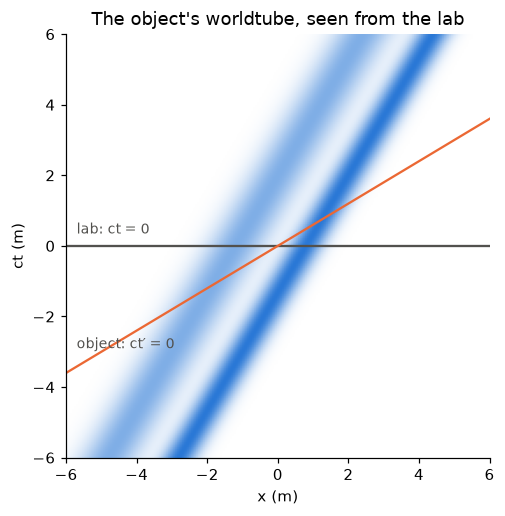

In [2]:
plane = spacetime(1)
rest_frame = xrf.ReferenceFrame.declared(("demo", "object"), plane)
lab = xrf.ReferenceFrame.declared(("demo", "laboratory"), plane)
matrix, gamma = boost([0.6])
lab_to_rest = xrf.AffineTransform(
    source=lab, target=rest_frame, matrix=matrix, translation=[0.0, 0.0]
)

x = np.linspace(-12, 12, 481)
profile = np.exp(-(((x - 1.0) / 0.6) ** 2)) + 0.6 * np.exp(-(((x + 1.5) / 1.0) ** 2))  # any shape
at_rest = grid(rest_frame, ct=np.linspace(-15, 15, 301), x=x) + profile

in_lab = at_rest.rf.resample_to(
    grid(lab, ct=np.linspace(-6, 6, 241), x=np.linspace(-6, 6, 241)), transform=lab_to_rest
)

fig, ax = plt.subplots(figsize=(5.2, 5.0))
ax.imshow(
    in_lab,
    origin="lower",
    extent=(-6, 6, -6, 6),
    cmap=LinearSegmentedColormap.from_list("", ["white", BLUE]),
)
ax.plot([-6, 6], [0, 0], color=INK, lw=1.5)
ax.plot([-6, 6], [-3.6, 3.6], color=ORANGE, lw=1.5)
ax.text(-5.7, 0.35, "lab: ct = 0", color=INK, fontsize=9)
ax.text(-5.7, -2.9, "object: ct′ = 0", color=INK, fontsize=9)
ax.set(xlabel="x (m)", ylabel="ct (m)", title="The object's worldtube, seen from the lab")
plt.show()

## 2. The pole and the barn

A 10 m pole flies at 0.8 c (γ = 5/3) through an 8 m barn. In the barn's frame the pole is 6 m
and fits inside; in the pole's frame the barn is 4.8 m and the pole sticks out at both ends.
Both statements are true: they are measurements on different "nows". Each object is defined in
its own rest frame and resampled into the other frame's instant.

In [3]:
barn_frame = xrf.ReferenceFrame.declared(("demo", "barn"), plane)
pole_frame = xrf.ReferenceFrame.declared(("demo", "pole"), plane)
matrix, gamma = boost([0.8])
barn_to_pole = xrf.AffineTransform(
    source=barn_frame, target=pole_frame, matrix=matrix, translation=[0.0, 0.0]
)

x = np.linspace(-15, 15, 1201)


def occupied(start, stop):
    return ((x >= start) & (x <= stop)).astype(float)


pole = grid(pole_frame, ct=np.linspace(-40, 40, 321), x=x) + occupied(-5, 5)  # 10 m at rest
barn = grid(barn_frame, ct=np.linspace(-40, 40, 321), x=x) + occupied(-4, 4)  # 8 m at rest

pole_in_barn = pole.rf.resample_to(grid(barn_frame, ct=[0.0], x=x), transform=barn_to_pole).isel(
    ct=0
)
barn_in_pole = barn.rf.resample_to(
    grid(pole_frame, ct=[0.0], x=x), transform=barn_to_pole.inverse()
).isel(ct=0)

step = x[1] - x[0]
print(f"barn frame: pole {float(pole_in_barn.sum()) * step:.2f} m, barn 8.00 m")
print(f"pole frame: barn {float(barn_in_pole.sum()) * step:.2f} m, pole 10.00 m")

barn frame: pole 6.03 m, barn 8.00 m
pole frame: barn 4.83 m, pole 10.00 m


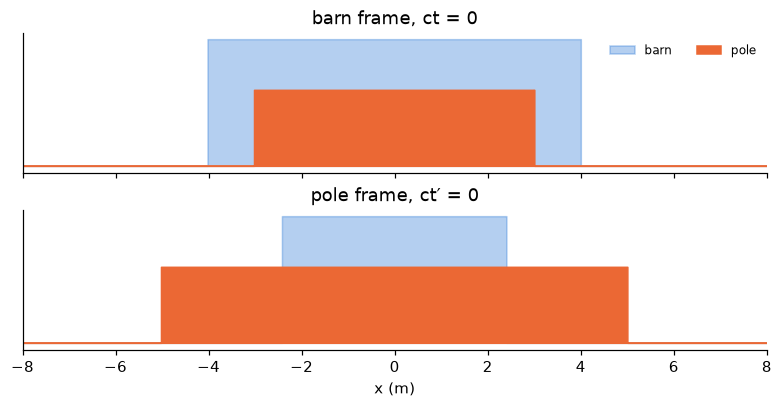

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(7, 3.6), sharex=True, constrained_layout=True)
views = [
    ("barn frame, ct = 0", occupied(-4, 4), pole_in_barn),
    ("pole frame, ct′ = 0", barn_in_pole, occupied(-5, 5)),
]
for ax, (title, barn_now, pole_now) in zip(axes, views, strict=True):
    ax.fill_between(x, 0, np.asarray(barn_now), color=BLUE, alpha=0.35, label="barn", step="mid")
    ax.fill_between(x, 0, np.asarray(pole_now) * 0.6, color=ORANGE, label="pole", step="mid")
    ax.set(title=title, yticks=[], xlim=(-8, 8))
axes[0].legend(loc="upper right", frameon=False, fontsize=8, ncol=2)
axes[1].set_xlabel("x (m)")
plt.show()

## 3. A grid of clocks flying past

A 6 × 6 m tile carries a clock in every square, all synchronized in the tile's own frame. It
flies diagonally at 0.8 c. Resampling the tile's spacetime field (checkerboard plus clock
readings) onto one instant of the lab shows two effects at once: the tile is contracted along
its motion, and its clocks, synchronized in their own frame, disagree in the lab. The reading
changes across the tile at a rate −γβ per metre along each axis of motion.

In [5]:
space = spacetime(2)
tile_frame = xrf.ReferenceFrame.declared(("demo", "tile"), space)
lab2 = xrf.ReferenceFrame.declared(("demo", "laboratory 2D"), space)
beta = 0.8 * np.array([1.0, 1.0]) / np.sqrt(2)
matrix, gamma = boost(beta)
lab_to_tile = xrf.AffineTransform(
    source=lab2, target=tile_frame, matrix=matrix, translation=[0.0, 0.0, 0.0]
)

s = np.linspace(-5, 5, 201)
X, Y = np.meshgrid(s, s, indexing="ij")
on_tile = ((np.abs(X) <= 3) & (np.abs(Y) <= 3)).astype(float)
squares = ((np.floor(X) + np.floor(Y)) % 2).astype(float)
times = np.linspace(-12, 12, 97)
tile = grid(tile_frame, ct=times, x=s, y=s)
fields = xr.Dataset(
    {
        "tile": tile + on_tile,
        "squares": tile + squares,
        "clock": tile + times[:, None, None],  # every clock shows its own frame's time
    }
)

lab_view = grid(lab2, ct=[0.0, 3.0], x=np.linspace(-4, 4, 161), y=np.linspace(-4, 4, 161))
seen = xr.Dataset(
    {name: field.rf.resample_to(lab_view, transform=lab_to_tile) for name, field in fields.items()}
).compute()

now = seen.isel(ct=0)
area_rest = float(on_tile.sum()) * 0.05**2
area_lab = float(now.tile.sum()) * 0.05**2
print(
    f"tile area: {area_rest:.2f} m² at rest, {area_lab:.2f} m² in the lab, ratio {area_lab / area_rest:.4f} (1/γ = {1 / gamma:.4f})"
)
left, right = (float(now.clock.interp(x=px, y=0.0)) for px in (-1.0, 1.0))
print(
    f"clock reading changes by {(right - left) / 2:.4f} per metre in x (−γβx = {-gamma * beta[0]:.4f})"
)

tile area: 36.60 m² at rest, 21.96 m² in the lab, ratio 0.6000 (1/γ = 0.6000)


clock reading changes by -0.9428 per metre in x (−γβx = -0.9428)


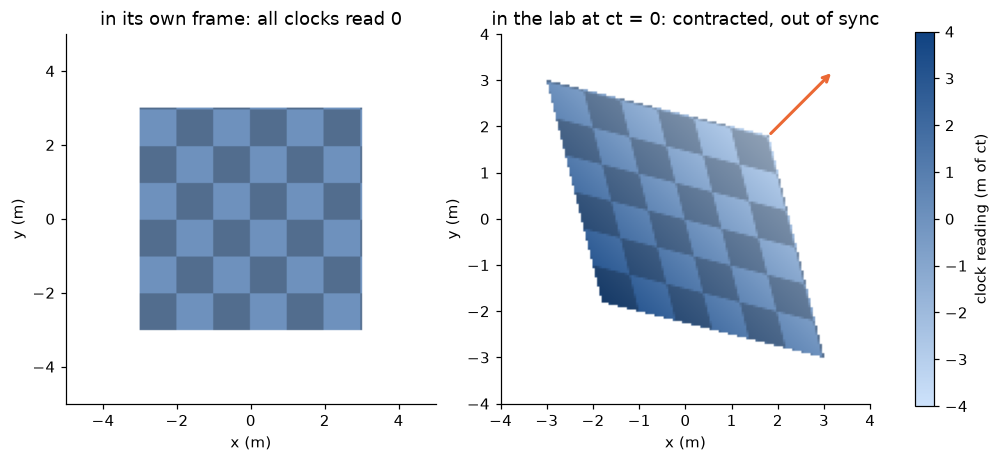

In [6]:
readings = LinearSegmentedColormap.from_list("readings", ["#cde2fb", "#104281"])


def picture(state, clock_range):
    """Tile squares shaded light/dark, coloured by the clock reading."""
    colour = readings(np.clip((state.clock - clock_range[0]) / np.ptp(clock_range), 0, 1))
    shade = 0.75 + 0.25 * np.asarray(state.squares)[..., None]
    rgb = colour[..., :3] * shade
    return np.where(np.asarray(state.tile)[..., None] > 0.5, rgb, 1.0).transpose(1, 0, 2)


rest_now = fields.sel(ct=0.0, method="nearest")
fig, axes = plt.subplots(1, 2, figsize=(9, 4.4), constrained_layout=True)
axes[0].imshow(picture(rest_now, (-4, 4)), origin="lower", extent=(-5, 5, -5, 5))
axes[0].set_title("in its own frame: all clocks read 0")
axes[1].imshow(picture(now, (-4, 4)), origin="lower", extent=(-4, 4, -4, 4))
axes[1].annotate(
    "", xy=(3.2, 3.2), xytext=(1.8, 1.8), arrowprops=dict(arrowstyle="->", color=ORANGE, lw=2)
)
axes[1].set_title("in the lab at ct = 0: contracted, out of sync")
for ax in axes:
    ax.set(xlabel="x (m)", ylabel="y (m)")
fig.colorbar(
    plt.cm.ScalarMappable(cmap=readings, norm=plt.Normalize(-4, 4)),
    ax=axes,
    shrink=0.8,
    label="clock reading (m of ct)",
)
plt.show()

**Time dilation** falls out of the same field, provided you follow *one* clock. The clock at
the origin at ct = 0 has moved to x = y = 3βᵢ by ct = 3. Watching a fixed lab position instead
shows a *different* clock at each moment, which is a classic trap.

In [7]:
start = float(seen.clock.isel(ct=0).interp(x=0.0, y=0.0))
same_clock = float(seen.clock.isel(ct=1).interp(x=3 * beta[0], y=3 * beta[1])) - start
fixed_spot = float(seen.clock.isel(ct=1).interp(x=0.0, y=0.0)) - start
print(f"in 3 m of lab time, the moving clock advances {same_clock:.4f} m   (3/γ = {3 / gamma:.4f})")
print(f"the reading at a fixed lab position changes by {fixed_spot:.4f} m   (a different clock)")

in 3 m of lab time, the moving clock advances 1.8000 m   (3/γ = 1.8000)
the reading at a fixed lab position changes by 5.0000 m   (a different clock)


## 4. Three dimensions, any direction

The same code works in 3+1 dimensions. A lumpy body at rest in its frame moves at 0.8 c along
the oblique direction (2, 1, 2)/3. On one instant of the lab, its spread along the motion
shrinks by 1/γ; across the motion it is unchanged.

In [8]:
space3 = spacetime(3)
body_frame = xrf.ReferenceFrame.declared(("demo", "body"), space3)
lab3 = xrf.ReferenceFrame.declared(("demo", "laboratory 3D"), space3)
direction = np.array([2.0, 1.0, 2.0]) / 3
matrix, gamma = boost(0.8 * direction)
lab_to_body = xrf.AffineTransform(
    source=lab3, target=body_frame, matrix=matrix, translation=np.zeros(4)
)

s = np.linspace(-7, 7, 71)
X, Y, Z = np.meshgrid(s, s, s, indexing="ij")


def blob(centre, width):
    return np.exp(
        -sum(((axis - c) / w) ** 2 for axis, c, w in zip((X, Y, Z), centre, width, strict=True))
    )


shape = blob((0, 0, 0), (1.6, 1.0, 0.8)) + 0.7 * blob((1.2, 0.6, -0.4), (0.5, 0.5, 0.5))
body = grid(body_frame, ct=np.linspace(-12, 12, 7), x=s, y=s, z=s) + shape

t = np.linspace(-3.5, 3.5, 57)
measured = (
    body.rf.resample_to(grid(lab3, ct=[0.0], x=t, y=t, z=t), transform=lab_to_body)
    .isel(ct=0)
    .compute()
)


def spread(values, axis):
    """Second moment of a density along a unit direction."""
    points = np.stack(
        np.meshgrid(*[values[name].values for name in ("x", "y", "z")], indexing="ij"), -1
    )
    weights = np.asarray(values) / float(values.sum())
    along = points @ axis
    centre = (weights * along).sum()
    return float((weights * (along - centre) ** 2).sum())


rest = xr.DataArray(shape, dims=("x", "y", "z"), coords={"x": s, "y": s, "z": s})
across = np.cross(direction, [0.0, 0.0, 1.0])
across /= np.linalg.norm(across)
print(
    f"along the motion: rms size ratio {np.sqrt(spread(measured, direction) / spread(rest, direction)):.4f}   (1/γ = {1 / gamma:.4f})"
)
print(
    f"across the motion: rms size ratio {np.sqrt(spread(measured, across) / spread(rest, across)):.4f}   (1)"
)

along the motion: rms size ratio 0.6022   (1/γ = 0.6000)
across the motion: rms size ratio 1.0048   (1)


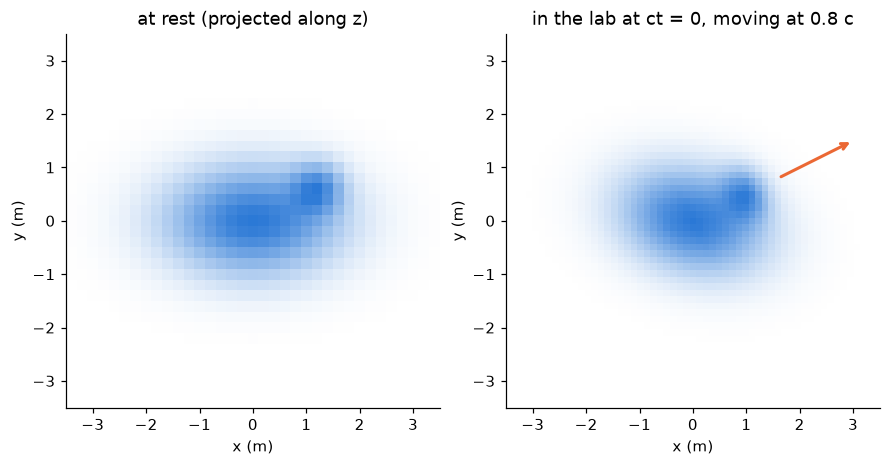

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4), constrained_layout=True)
white_to_blue = LinearSegmentedColormap.from_list("", ["white", BLUE])
axes[0].imshow(
    rest.sel(x=slice(-3.5, 3.5), y=slice(-3.5, 3.5)).max("z").T,
    origin="lower",
    extent=(-3.5, 3.5, -3.5, 3.5),
    cmap=white_to_blue,
)
axes[0].set_title("at rest (projected along z)")
axes[1].imshow(
    measured.max("z").T, origin="lower", extent=(-3.5, 3.5, -3.5, 3.5), cmap=white_to_blue
)
axes[1].annotate(
    "", xy=(3.0, 1.5), xytext=(1.6, 0.8), arrowprops=dict(arrowstyle="->", color=ORANGE, lw=2)
)
axes[1].set_title("in the lab at ct = 0, moving at 0.8 c")
for ax in axes:
    ax.set(xlabel="x (m)", ylabel="y (m)")
plt.show()

## 5. Identity is not a transformation

`rf.assume_frame` declares that an array is *already* in another frame: it relabels, it does not
move anything. Relabelling the body as "lab" and slicing at the lab's ct = 0 gives the body's
rest shape, not the contracted one. Only an actual transform between frames carries physics;
xarrayrf keeps the two apart and refuses to mix frames silently.

In [10]:
relabelled = (
    body.rf.assume_frame(lab3).rf.resample_to(grid(lab3, ct=[0.0], x=t, y=t, z=t)).isel(ct=0)
)
print(
    f"along the motion after relabelling: ratio {np.sqrt(spread(relabelled, direction) / spread(rest, direction)):.4f} (no contraction)"
)
try:
    body.rf.resample_to(grid(lab3, ct=[0.0], x=t, y=t, z=t))
except ValueError as error:
    print("without a transform:", error)

along the motion after relabelling: ratio 0.9980 (no contraction)
without a transform: the target frame ('demo', 'laboratory 3D') and the source frame ('demo', 'body') are different frames; supply the transform between them, such as a registration result


## What an observer would actually *see*

Everything above is a *measurement*: where the parts of an object are at one instant of a frame.
What a camera records is different: light from different parts left at different times (the
observer's past light cone), directions are aberrated, and colours are Doppler shifted. The
result is the famous Terrell–Penrose rotation: a fast sphere looks rotated, not squashed. In
xarrayrf terms that is resampling onto a light-cone geometry instead of a constant-time slice;
the design is sketched in `docs/dev/architecture/relativistic_viewing_design.md` and shares its missing
pieces (angular coordinates, nonlinear transforms) with astronomy and geography.